# Install dependances

In [12]:
import pandas as pd
import numpy as np
import folium
import branca.colormap as cm
import matplotlib.pyplot as plt

## Import all files

In [15]:


# 1. Charger les fichiers GTFS
stops = pd.read_csv('data/stops.txt')
stop_times = pd.read_csv('data/stop_times.txt')
trips = pd.read_csv('data/trips.txt')
routes = pd.read_csv('data/routes.txt')
agence=pd.read_csv('data/agency.txt')
transfers=pd.read_csv("data/pathways.txt")
shapes=pd.read_csv('data/shapes.txt')



In [11]:
print("Aperçu des arrêts :")
print(stops.head())

print("\nAperçu des lignes :")
print(routes.head())

Aperçu des arrêts :
            stop_id            stop_name  stop_lat  stop_lon  location_type  \
0  node/10218963489           Chez Rifat  5.349222 -3.975893            NaN   
1  node/10218963490     Carrefour garage  5.347851 -3.975529            NaN   
2  node/10218963491    Gorille carrefour  5.346528 -3.975153            NaN   
3  node/10218963492     Carrefour lavage  5.345986 -3.974986            NaN   
4  node/10218963494  Carrefour chefferie  5.341507 -3.974229            NaN   

   parent_station  zone_id  level_id  stop_timezone  platform_code  \
0             NaN      NaN       NaN            NaN            NaN   
1             NaN      NaN       NaN            NaN            NaN   
2             NaN      NaN       NaN            NaN            NaN   
3             NaN      NaN       NaN            NaN            NaN   
4             NaN      NaN       NaN            NaN            NaN   

   wheelchair_boarding  stop_code  stop_url  stop_desc  
0                  NaN     

## Analyse des temps de trajet par ligne

In [7]:

# 2. Convertir les heures en secondes
def time_to_seconds(t):
    try:
        h, m, s = map(int, t.split(':'))
        return h * 3600 + m * 60 + s
    except:
        return np.nan

stop_times['arrival_sec'] = stop_times['arrival_time'].apply(time_to_seconds)
stop_times['departure_sec'] = stop_times['departure_time'].apply(time_to_seconds)

# 3. Calculer la durée de chaque trip
trip_durations = stop_times.groupby('trip_id').agg({
    'arrival_sec': 'max',
    'departure_sec': 'min'
}).reset_index()

trip_durations['duration_sec'] = trip_durations['arrival_sec'] - trip_durations['departure_sec']

# 4. Joindre les trips aux routes
trip_routes = trips[['trip_id', 'route_id']].merge(trip_durations[['trip_id', 'duration_sec']], on='trip_id')

# 5. Calculer la durée moyenne par ligne (route_id)
route_duration = trip_routes.groupby('route_id')['duration_sec'].mean().reset_index()
route_duration['duration_min'] = route_duration['duration_sec'] / 60  # en minutes

# 6. Joindre les noms de ligne
route_duration = route_duration.merge(routes[['route_id', 'route_long_name']], on='route_id')

# 7. Calculer les positions moyennes
trip_stop = trips[['trip_id', 'route_id']].merge(stop_times, on='trip_id')
stop_route = trip_stop.merge(stops[['stop_id', 'stop_lat', 'stop_lon']], on='stop_id')

route_coords = stop_route.groupby('route_id').agg({
    'stop_lat': 'mean',
    'stop_lon': 'mean'
}).reset_index()

# 8. Joindre avec les durées
route_map_data = route_duration.merge(route_coords, on='route_id')

# 9. Générer la carte
m = folium.Map(location=[5.35, -4.02], zoom_start=11)  # centre sur Abidjan

min_dur = route_map_data['duration_min'].min()
max_dur = route_map_data['duration_min'].max()

# Colormap jaune->rouge
colormap = cm.linear.YlOrRd_09.scale(min_dur, max_dur)
colormap.caption = 'Durée moyenne des trajets (minutes)'
colormap.add_to(m)

for i, row in route_map_data.iterrows():
    color = colormap(row['duration_min'])

    folium.CircleMarker(
        location=[row['stop_lat'], row['stop_lon']],
        radius=8,
        color=color,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(f"Ligne: {row['route_long_name']}<br>Durée Moyenne: {row['duration_min']:.1f} min", max_width=300)
    ).add_to(m)

# 10. Afficher la carte
m.save('carte_chaleur_duree.html')
m


In [16]:
nb_stops = stops['stop_id'].nunique()
nb_routes = routes['route_id'].nunique()
nb_trips = trips['trip_id'].nunique()
nb_shapes = shapes['shape_id'].nunique()

print(f"Nombre total d’arrêts     : {nb_stops}")
print(f"Nombre total de lignes    : {nb_routes}")
print(f"Nombre total de trajets   : {nb_trips}")
print(f"Nombre total d’itinéraires (shapes) : {nb_shapes}")


Nombre total d’arrêts     : 4834
Nombre total de lignes    : 490
Nombre total de trajets   : 980
Nombre total d’itinéraires (shapes) : 974


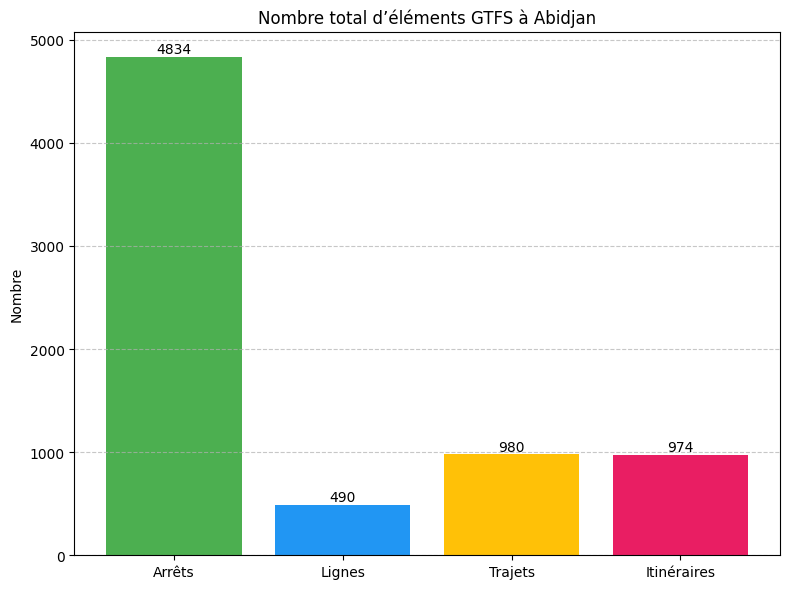

In [18]:

# Données à afficher
labels = ['Arrêts', 'Lignes', 'Trajets', 'Itinéraires']
values = [nb_stops, nb_routes, nb_trips, nb_shapes]

# Création du graphique
plt.figure(figsize=(8, 6))
bars = plt.bar(labels, values, color=['#4CAF50', '#2196F3', '#FFC107', '#E91E63'])

# Ajouter les valeurs sur les barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, f'{int(yval)}', ha='center', va='bottom')

# Personnaliser
plt.title('Nombre total d’éléments GTFS à Abidjan')
plt.ylabel('Nombre')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Afficher
plt.show()


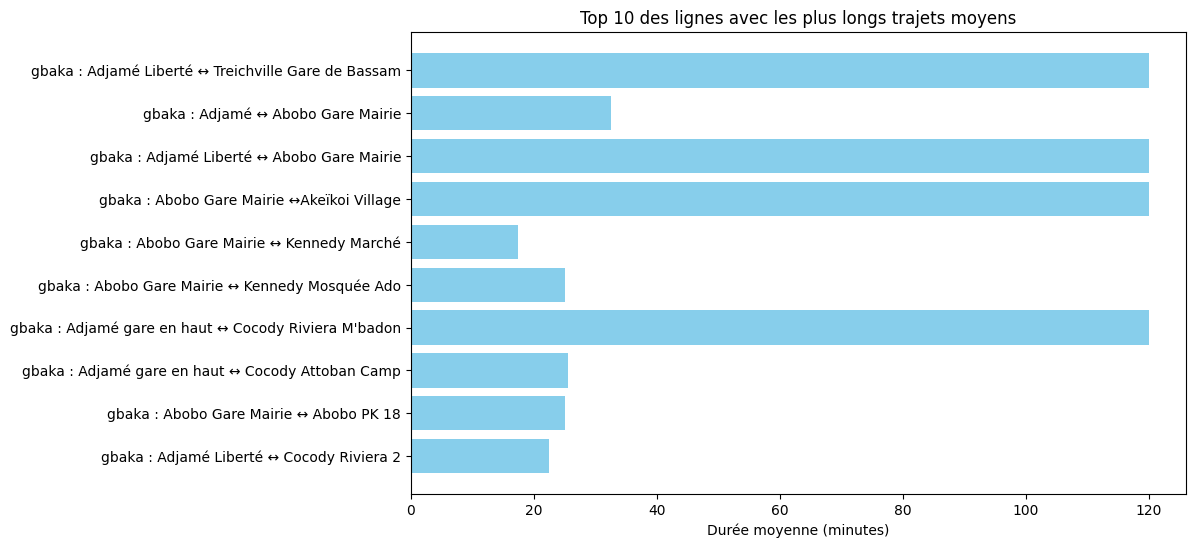

In [13]:


top_routes = route_duration.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_routes['route_long_name'], top_routes['duration_min'], color='skyblue')
plt.xlabel('Durée moyenne (minutes)')
plt.title('Top 10 des lignes avec les plus longs trajets moyens')
plt.gca().invert_yaxis()
plt.show()
